# 03: Model Development (Price Prediction)

This notebook satisfies the Chapter 4 rubric using the refactored feature-target pipeline.

## Chapter 4: Model Development

- Primary Model (Assigned Technique): **Linear Regression**
- Two Comparative Models: **Ridge Regression**, **Huber Regression**
- Hyperparameter Tuning: Time-series cross-validation with grid search
- Model Justification: Compare generalization metrics and residual behavior

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)

In [53]:
CONFIG_PATH = Path("../data/processed/modeling_config.json")
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 01 first to generate modeling_config.json.")

import json
cfg = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))

data_csv = Path(cfg["data_csv"])
df = pd.read_csv(data_csv, index_col=0, parse_dates=True)

feature_cols = cfg["train_feature_cols"]
target_col = cfg["target_col"]

In [54]:
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Configured target:", target_col)
print("Configured features:", feature_cols)
print(f"Train rows: {len(train_df)}")
print(f"Test rows:  {len(test_df)}")
print(f"Train period: {train_df.index.min().date()} -> {train_df.index.max().date()}")
print(f"Test period:  {test_df.index.min().date()} -> {test_df.index.max().date()}")


Configured target: target_close_1d
Configured features: ['rsi_14', 'macd_hist_12_26_9', 'bb_bandwidth_20_2', 'adx_14', 'obv', 'adj_close_smooth', 'ema_20', 'atr_14']
Train rows: 977
Test rows:  245
Train period: 2021-05-28 -> 2025-04-17
Test period:  2025-04-21 -> 2026-04-10


In [ ]:
# Primary model: Linear Regression
lin_model = LinearRegression()

lin_model.fit(X_train, y_train)
lin_pred_train = lin_model.predict(X_train)
lin_pred_test = lin_model.predict(X_test)


lin_metrics = {"Model": "LinearRegression", 
               "MAE": mean_absolute_error(y_test, lin_pred_test),
               "RMSE": np.sqrt(mean_squared_error(y_test, lin_pred_test)),
               "MAPE": mean_absolute_percentage_error(y_test, lin_pred_test),
               "R2": r2_score(y_test, lin_pred_test)
               }

pd.DataFrame([lin_metrics]).round(4)


ValueError: If using all scalar values, you must pass an index

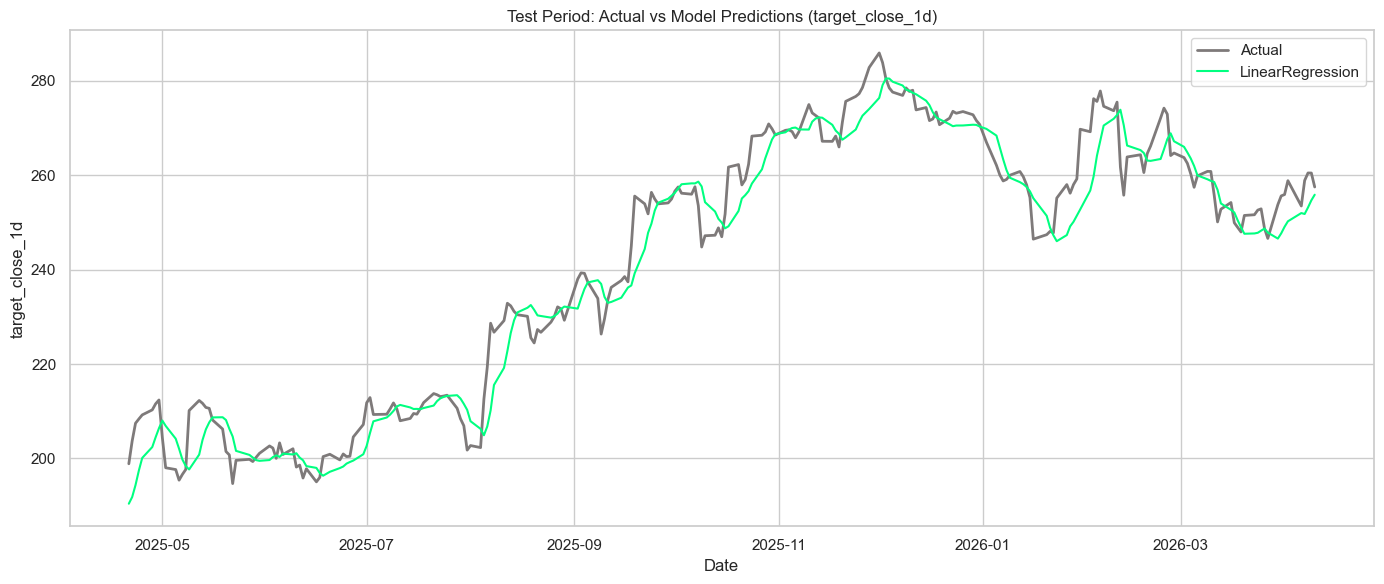

In [57]:
pred_df = pd.DataFrame(index=y_test.index)
pred_df["Actual"] = y_test
pred_df["LinearRegression"] = lin_pred_test

plt.figure(figsize=(14, 6))
plt.plot(pred_df.index, pred_df["Actual"], label="Actual", linewidth=2, color="#7E7A7A")
plt.plot(pred_df.index, pred_df["LinearRegression"], label="LinearRegression", color="#00FF80")
plt.title(f"Test Period: Actual vs Model Predictions ({target_col})")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.tight_layout()
plt.show()


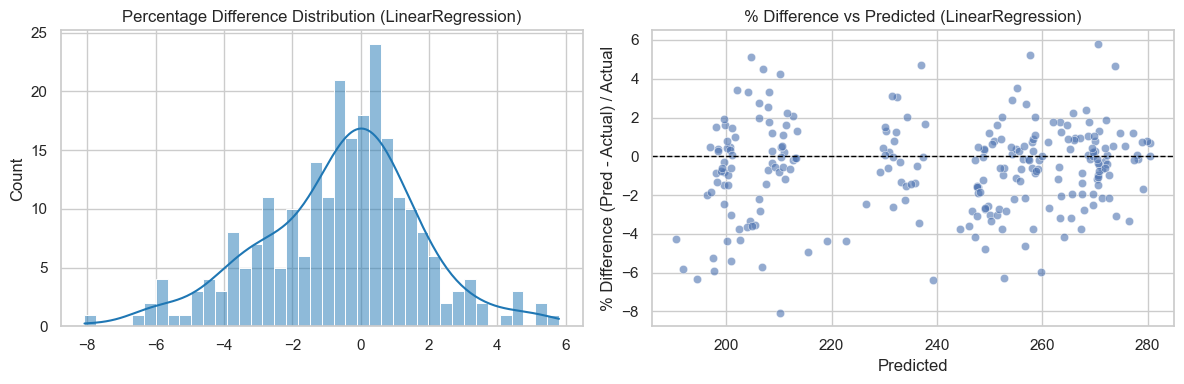

In [58]:

y_test_arr = np.asarray(y_test)
best_pred_arr = np.asarray(lin_pred_test)
pct_diff = np.where(y_test_arr != 0, ((best_pred_arr - y_test_arr) / y_test_arr) * 100, np.nan)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(pct_diff, bins=40, kde=True, ax=axes[0], color="#1f77b4")
axes[0].set_title(f"Percentage Difference Distribution (LinearRegression)")

sns.scatterplot(x=best_pred_arr, y=pct_diff, alpha=0.6, ax=axes[1])
axes[1].axhline(0, linestyle="--", color="black", linewidth=1)
axes[1].set_title(f"% Difference vs Predicted (LinearRegression)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("% Difference (Pred - Actual) / Actual")

plt.tight_layout()
plt.show()

In [59]:
# Model interpretation views for linear-family models
lin_coef = pd.DataFrame({
    "feature": feature_cols,
    "coef_linear": lin_model.coef_,
})

lin_coef.sort_values("coef_linear", ascending=False)


,feature,coef_linear
5,adj_close_smooth,1.598287e+00
2,bb_bandwidth_20_2,9.283224e-02
4,obv,1.817207e-10
3,adx_14,-1.473260e-02
0,rsi_14,-2.557696e-02
1,macd_hist_12_26_9,-5.238674e-02
7,atr_14,-2.487588e-01
6,ema_20,-6.296823e-01


## Model Justification

- Primary model is Linear Regression (assigned technique), giving a transparent baseline with interpretable coefficients.
- Ridge handles multicollinearity among trend-heavy features via L2 shrinkage.
- Huber regression is robust to outliers and can stabilize fit when price jumps create large residuals.
- Final recommendation should be based on the best test RMSE/MAE plus residual stability, not only training fit.